## Linear Regression from scratch

### Import the libraries

First of all, let's import the libraries that we will need

In [3]:
import numpy as np
import math
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

### Building the Linear Regression model

The objective of this script is to build a Linear Regression model without using only Numpy library.

In [4]:
class RegressioneLineare():

    def __init__(self):
       self.coefficienti = None
       self.y_predicted = None
    
    def fit(self,X, y): #Take as input X_train and y_train
        final_X = X.copy()
        final_X.insert(0, 'ones', 1)    #Add to X a column of all 1
        X_mat = final_X.to_numpy()  #Convert X and y into a numpy object (we need this to do the mathematical operations)
        y_arr = y.to_numpy()
        coefficienti = np.linalg.inv(np.matmul(X_mat.T,X_mat))@np.matmul(X_mat.T,y_arr)
        self.coefficienti = coefficienti     #Assign the values (in this way we can use these values also outside the fit function)
    
    def predict(self,test_data):    #Take as input X_test
        mat_testdata = test_data.copy()
        mat_testdata.insert(0,'ones',1)      #Add a column of all 1 (like during the training)
        mat_testdata = mat_testdata.to_numpy()
        y_predicted = mat_testdata@self.coefficienti   #Compute the predicted values of y
        self.y_predicted = y_predicted

        return self.y_predicted
    
    #Compute the R^2
    def score(self,y_test):
        y_test_arr = y_test.to_numpy()
        y_mean = y_test_arr.mean()
        SST = np.sum((y_test_arr - y_mean)**2)
        SSE = np.sum((y_test_arr - self.y_predicted)**2)

        R_square = 1- (SSE/SST)

        return print(f"R^2: {R_square}")

We have built the model, now let's try it with a simple dataset

### Loading Dataset

To try the model I choose the Height VS Weight dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("burnoutminer/heights-and-weights-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\loren\.cache\kagglehub\datasets\burnoutminer\heights-and-weights-dataset\versions\1


In [6]:
dataset = pd.read_csv("C:/Users/loren/.cache/kagglehub/datasets/burnoutminer/heights-and-weights-dataset/versions/1/SOCR-HeightWeight.csv")
dataset.head()


,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


As we can see there are only 2 variables inside the dataset.

### Preprocessing of the dataset

In [70]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           25000 non-null  int64  
 1   Height(Inches)  25000 non-null  float64
 2   Weight(Pounds)  25000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 586.1 KB


There aren't missing values

In [71]:

print(f"There are {dataset.duplicated().sum()} duplicate rows in the dataset")

There are 0 duplicate rows in the dataset


In [72]:
final_df = dataset.drop("Index", axis = 1)
final_df

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


I dropped the Index column, because we do not need it

### Linear Correlation

In [73]:
final_df.corr()

,Height(Inches),Weight(Pounds)
Height(Inches),1.000000,0.502859
Weight(Pounds),0.502859,1.000000


From the matrix of the correlations we can see that there is a positive linear relationship between the 2 variables, this means that when one of the 2 variables increases, also the other does it.

### Split the dataset in train and test

In [74]:
feature = final_df[["Weight(Pounds)"]] #mettiamo doppie parentesi, perchè deve essere un dataframe
target = final_df["Height(Inches)"] # va bene come serie (singola colonna), quindi non mettiamo doppie parentesi

X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size = 0.2, random_state=42)

### My Linear Regression

Let's apply the model that i built before to these data and see the results

In [ ]:
#Create the model
modello = RegressioneLineare()

#Estimate the parameters of the model on the train set
modello.fit(X_train,y_train)

#Predict the values of y (in our case Height)
y_pred = modello.predict(X_test)

#Compute the R^2
modello.score(y_test)



R^2: 0.26055631630449805


It is possible to see that the R^2 is very low. In particular, our model explains only 26% of the variability of the data. However, if we see again the correlation between the 2 variables, it is around 0.502. We can approximate the **R^2** as **r^2** (the square of the linear correlation). If we do (o.502)^2 it is equal to 0.26, that is the value of our R^2. So, we obtain bad results not because the model is not build in a good way, but because of the data. To find better results, it is better to use another model.

### Scatterplot of the Regression line

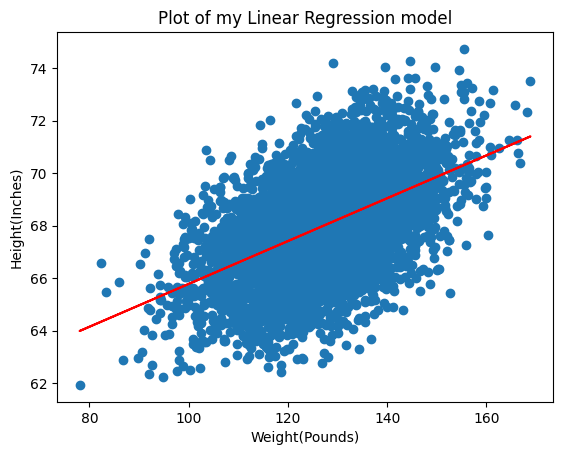

In [76]:
plt.scatter(X_test,y_test)
plt.plot(X_test, y_pred, color = 'r')

plt.xlabel("Weight(Pounds)")
plt.ylabel("Height(Inches)")
plt.title("Plot of my Linear Regression model")
plt.show()

### Linear Regression from Sklearn

Let's compare the results of the model built before, with the one of the library Scikit-Learn.

In [77]:
lin = LinearRegression()
lin.fit(X_train,y_train)
md_y_pred = lin.predict(X_test)
r2_score(y_test, md_y_pred)


0.26055631630450127

The value of the R^2 metric is basically the same. This confirm what said before.